# kT-RAM Neural Core — Single-Synapse Lesson (Milestone 1)

Reproduces the canonical Knowm **Synapse** lesson (`04_Synapse_REVIEW`) on the new 2-1
neural-lane architecture. A single synapse is the smallest lane: one address space, one
differential pair, one device per side, selected by the fixed AAT `z = (0,)`.

One instruction per `evaluate()` call; the old combined `execute(read, feedback)` is just
two sequential calls. Validate the panels here against the lesson's `_img/` figures.


## Setup

On Colab this installs the package from GitHub. Locally, it's a no-op if already installed.


In [ ]:
# On Colab this installs the package from GitHub. Locally it is a no-op if already installed.
try:
    import ktram_neural_core  # noqa: F401
except ModuleNotFoundError:
    %pip install -q "git+https://github.com/knowm/ktram-neural-core.git#subdirectory=python" matplotlib


In [2]:
import matplotlib.pyplot as plt
from ktram_neural_core import Core

Z = (0,)  # the single-synapse AAT: address 0 in the one space

def execute_n(core, read, feedback, n):
    """Repeat evaluate(read); evaluate(feedback) n times, recording y/Ga/Gb.
    feedback=None makes only the read call (the old XX no-op)."""
    lane = core.lane(0)
    ys, gas, gbs = [], [], []
    for _ in range(n):
        y = lane.evaluate(Z, read)
        if feedback is not None:
            lane.evaluate(Z, feedback)
        ga, gb = core.read_gab(0, Z)
        ys.append(y); gas.append(ga); gbs.append(gb)
    return ys, gas, gbs

def rails(core):
    d = core.lane(0).spaces[0].a.device_at(0)
    return d.GMIN, d.GMAX

def plot(traces, title, core, axrow=None):
    ys, gas, gbs = traces
    if axrow is None:
        _, axrow = plt.subplots(1, 2, figsize=(11, 3.4))
    axrow[0].plot(ys, lw=1.2); axrow[0].set_ylim(-1.05, 1.05)
    axrow[0].axhline(0, color='0.85', lw=0.8); axrow[0].set_title(f'y | {title}')
    axrow[1].plot(gas, label='Ga'); axrow[1].plot(gbs, label='Gb', color='tab:green')
    gmin, gmax = rails(core); axrow[1].set_ylim(gmin, gmax)
    axrow[1].set_title(f'Ga, Gb | {title}'); axrow[1].legend()
    for a in axrow: a.grid(True, color='0.93')
    return axrow

## 1. Pulse up/down — the headline plot
`(FF, RH)x5000` then `(FF, RL)x5000`. Byte is linear and plateaus at **±0.5** (the
half-up rounding ceiling); Float sweeps to **±1**. Compare `Byte_Medium.png` / `Float_Medium.png`.


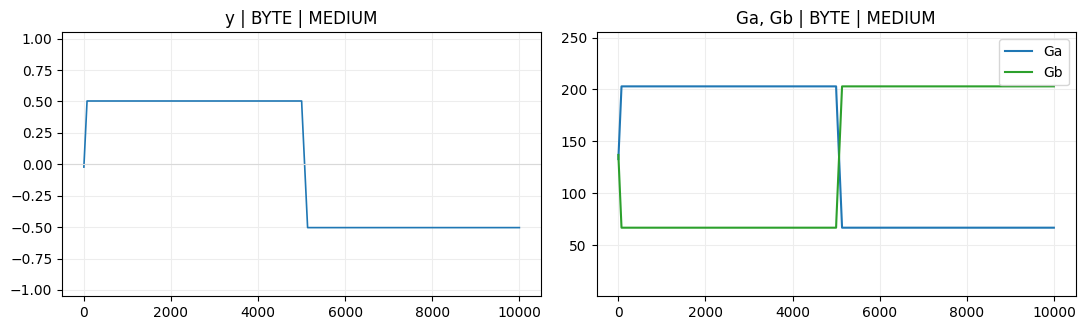

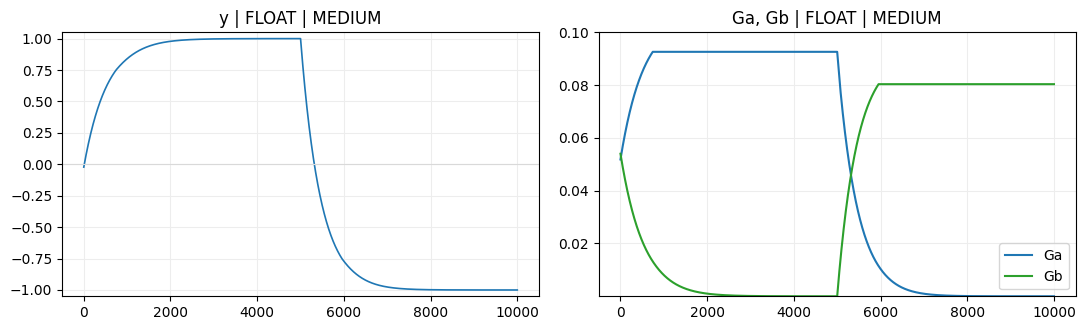

In [3]:
for model in ('byte', 'float'):
    core = Core(1, 1, model=model, init='medium', seed=1)
    up = execute_n(core, 'FF', 'RH', 5000)
    dn = execute_n(core, 'FF', 'RL', 5000)
    traces = (up[0]+dn[0], up[1]+dn[1], up[2]+dn[2])
    plot(traces, f'{model.upper()} | MEDIUM', core)
    plt.tight_layout(); plt.show()

## 2. The five feedback combos (Float / Medium)
`FF-RH` (up), `FF-RL` (down), `FF-RU` (Hebbian, away from 0), `FF-RA` (anti-Hebbian, to 0),
`FF-RZ` (decay, to 0). Each driven from the same start.


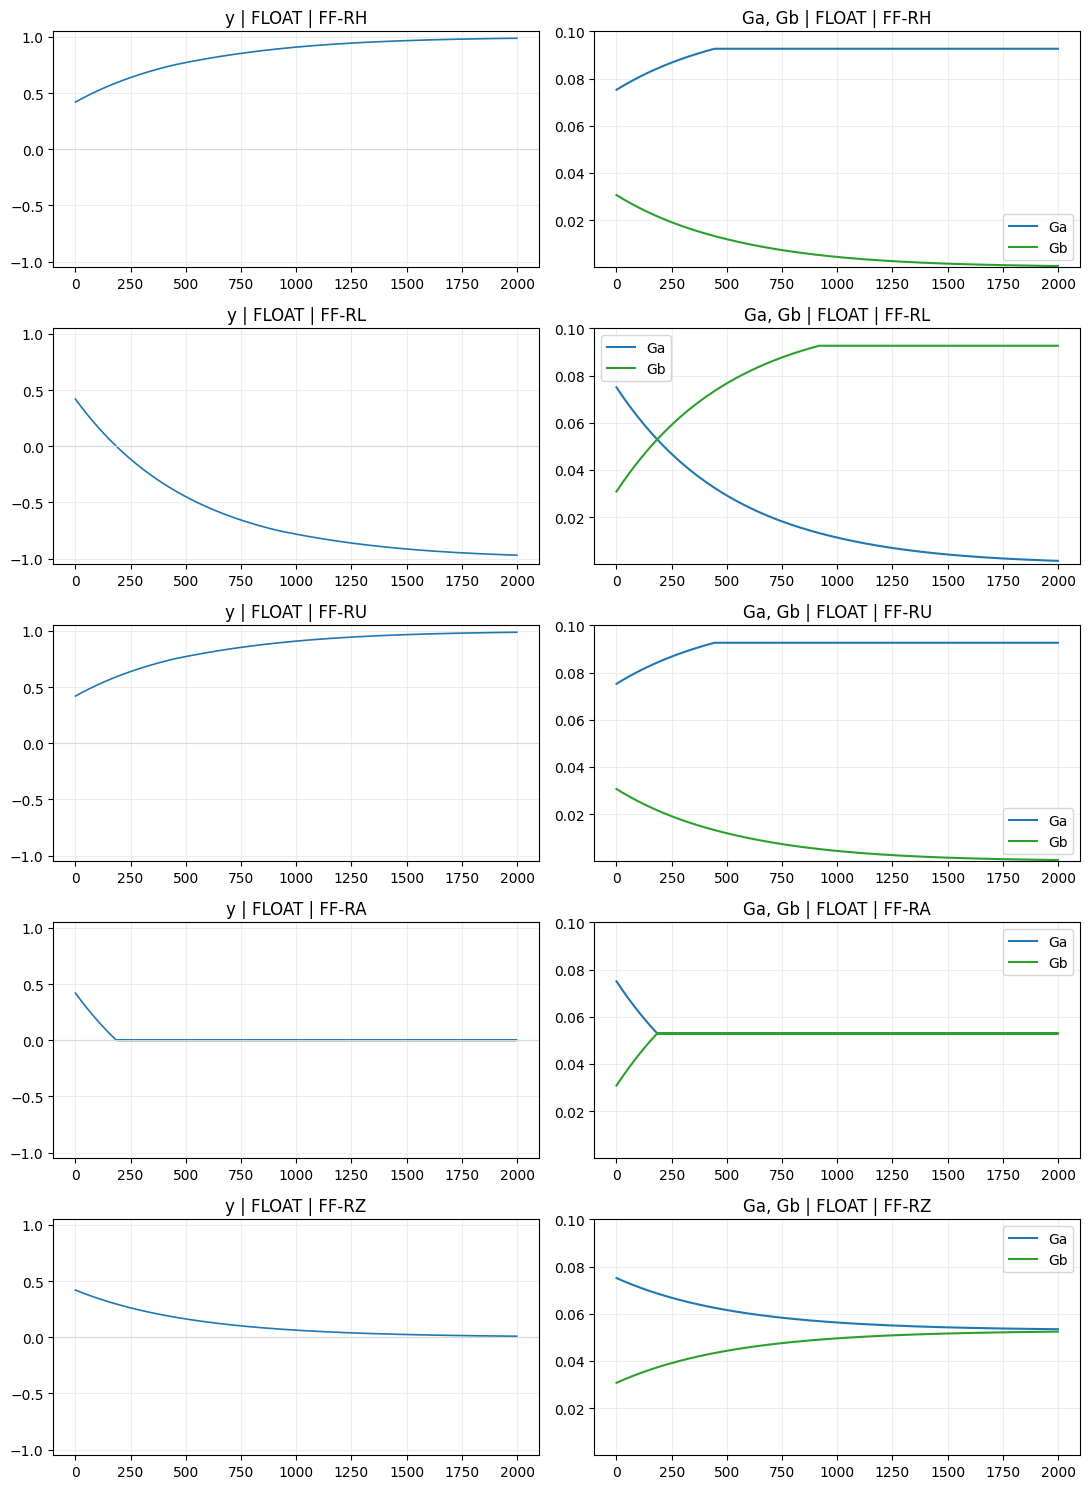

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(11, 15))
for row, combo in zip(axes, ['RH', 'RL', 'RU', 'RA', 'RZ']):
    core = Core(1, 1, model='float', init='medium', seed=1)
    # nudge to a nonzero start so RU/RA/RZ have something to act on
    execute_n(core, 'FF', 'RH', 300)
    traces = execute_n(core, 'FF', combo, 2000)
    plot(traces, f'FLOAT | FF-{combo}', core, row)
plt.tight_layout(); plt.show()

## 3. Read decay vs growth (Float)
`FF-XX` is **anti-Hebbian**: both devices saturate up, `y -> 0`. `RF-XX` is **Hebbian**:
the less-conductive device runs away, `y -> ±1`. Compare `FF-XX_Float.png` / `RF-XX_Float.png`.


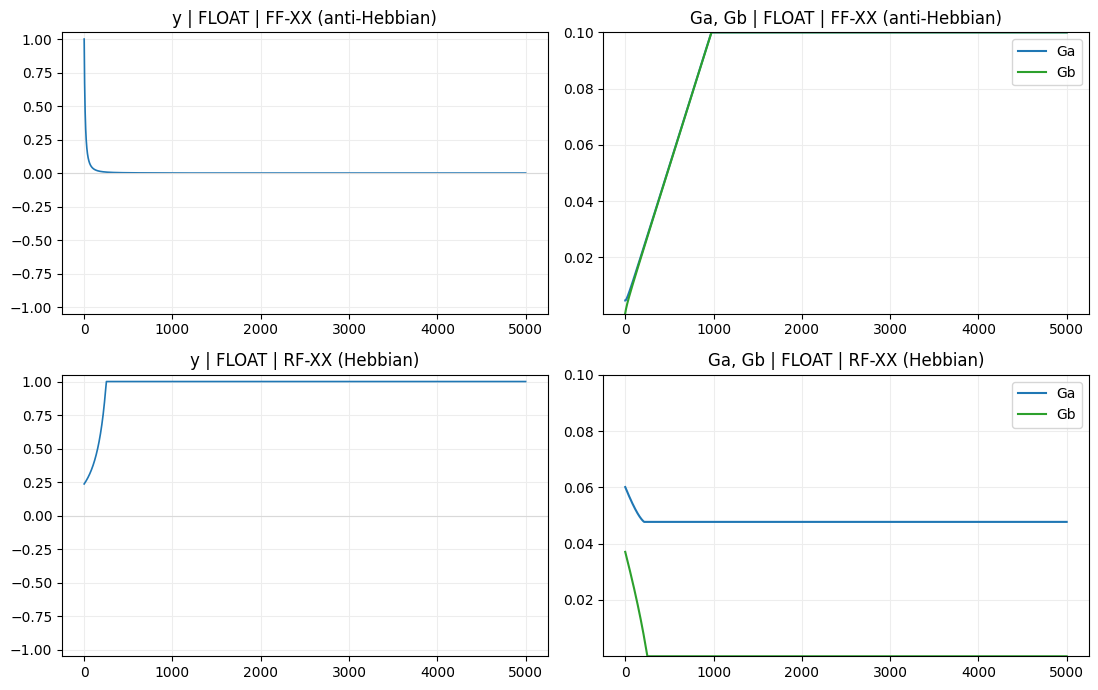

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
core = Core(1, 1, model='float', init='low_noise', seed=2)
plot(execute_n(core, 'FF', None, 5000), 'FLOAT | FF-XX (anti-Hebbian)', core, axes[0])
core = Core(1, 1, model='float', init='medium', seed=3)
plot(execute_n(core, 'RF', None, 5000), 'FLOAT | RF-XX (Hebbian)', core, axes[1])
plt.tight_layout(); plt.show()

## 4. RS memristor — sub-threshold read and FF-XX
RS uses the model-aware default `pulse_width = 1e-8`. `FFLV-XX` stays put (sub-threshold);
`FF-XX` saturates float-like. Compare `FFLV-XX_RS_Mem.png` / `FF-XX_RS_Mem.png`.


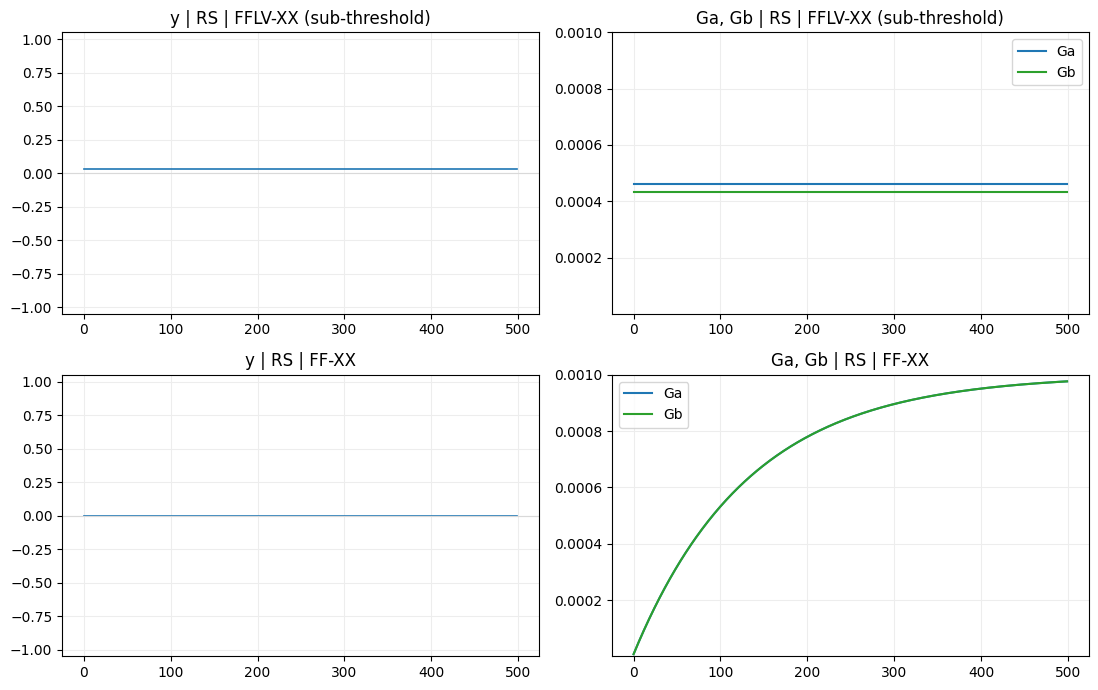

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
core = Core(1, 1, model='rs', init='medium', seed=5)
plot(execute_n(core, 'FFLV', None, 500), 'RS | FFLV-XX (sub-threshold)', core, axes[0])
core = Core(1, 1, model='rs', init='low_noise', seed=4)
plot(execute_n(core, 'FF', None, 500), 'RS | FF-XX', core, axes[1])
plt.tight_layout(); plt.show()

## 5. MSS — stochastic, and the RNG demo
MSS drives at **±0.25** (threshold ~0.27 V). The RNG demo: `(FF, RA)x500` then
`(FF, RZ)x500` on `MEDIUM_NOISE` — the synapse oscillates about zero and intrinsic noise
makes the digitized final read a fair bit. Compare `RNG.png`. Run many seeds for the histogram.


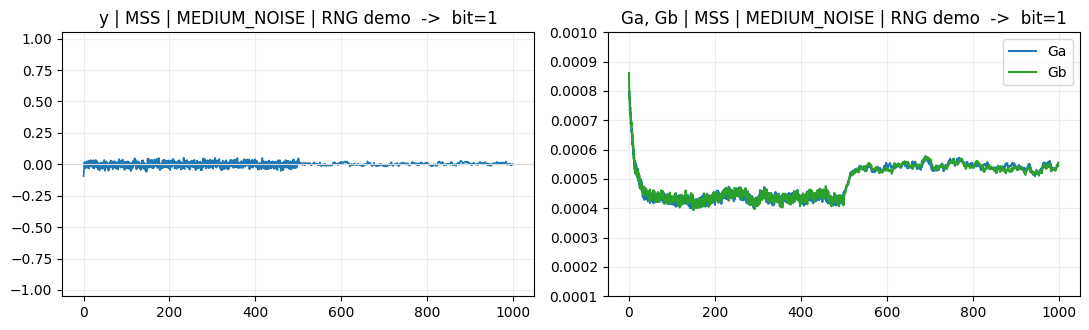

In [7]:
core = Core(1, 1, model='mss', init='medium_noise', seed=6)
a = execute_n(core, 'FF', 'RA', 500)
b = execute_n(core, 'FF', 'RZ', 500)
traces = (a[0]+b[0], a[1]+b[1], a[2]+b[2])
bit = 1 if traces[0][-1] > 0 else 0
plot(traces, f'MSS | MEDIUM_NOISE | RNG demo  ->  bit={bit}', core)
plt.tight_layout(); plt.show()

95/200 ones  (48%)


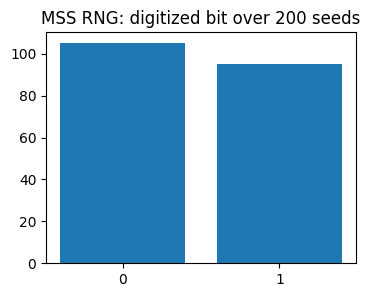

In [8]:
# Fair-bit check: digitize the final read across many seeds.
bits = []
for s in range(200):
    core = Core(1, 1, model='mss', init='medium_noise', seed=s)
    execute_n(core, 'FF', 'RA', 500)
    y_gab = execute_n(core, 'FF', 'RZ', 500)
    bits.append(1 if y_gab[0][-1] > 0 else 0)
ones = sum(bits)
print(f'{ones}/{len(bits)} ones  ({100*ones/len(bits):.0f}%)')
plt.figure(figsize=(4, 3)); plt.bar([0, 1], [bits.count(0), bits.count(1)])
plt.xticks([0, 1]); plt.title('MSS RNG: digitized bit over 200 seeds'); plt.show()